In [1]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import random, math
from sklearn.metrics.pairwise import cosine_similarity
import re

c:\Users\s223128143\AppData\Local\miniconda3\envs\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
hanoi = pd.read_csv("hanoi.csv")
qa_df = pd.read_csv("qa_dataset.csv")
# Build document corpus
def build_document(row):
    parts = [
        str(row['property_type_name']),
        f"quận {row['district_name']}",
        f"{row['bedroom_count']:.0f} phòng ngủ" if pd.notna(row['bedroom_count']) else "",
        f"diện tích {row['area']} mét vuông" if pd.notna(row['area']) else "",
        f"giá {row['Billion VND']:.2f} tỷ đồng",
    ]
    return " ".join(p for p in parts if p)

hanoi['document'] = hanoi.apply(build_document, axis=1)
docs = hanoi["document"].tolist()

# Build (query, passage) pairs for MNR loss
Use all 3 variants as anchors to triple the training size. 

In [3]:
def build_pairs(qa_df, docs, seed=42):
    random.seed(seed)
    pairs = []
    for i in range(len(docs)):
        for v in ["clean", "address_variant", "code_switched"]:
            q = qa_df[v].iloc[i]
            d = docs[i]
            if q.strip() and d.strip():
                pairs.append(InputExample(texts=[f"query: {q}", f"passage: {d}"]))
    random.shuffle(pairs)
    return pairs

In [4]:
i = 0
for v in ["clean", "address_variant", "code_switched"]:
    q = qa_df[v].iloc[i]
    d = docs[i]
    print(f"Variant: {v}")
    print(f"  query: {q}")
    print(f"  passage: {d}")
    print()

Variant: clean
  query: Nhà 4 phòng ngủ tại quận Bắc Từ Liêm, diện tích 37 mét vuông, giá dưới 7.95 tỷ đồng
  passage: Nhà quận Bắc Từ Liêm 4 phòng ngủ diện tích 37.0 mét vuông giá 7.45 tỷ đồng

Variant: address_variant
  query: Nhà 4 PN tại Q Bắc Từ Liêm, 37 mét vuông, giá dưới 7.95 tỷ
  passage: Nhà quận Bắc Từ Liêm 4 phòng ngủ diện tích 37.0 mét vuông giá 7.45 tỷ đồng

Variant: code_switched
  query: house 4 BR tại Bắc Từ Liêm, 37 mét vuông, giá dưới 7.95 B
  passage: Nhà quận Bắc Từ Liêm 4 phòng ngủ diện tích 37.0 mét vuông giá 7.45 tỷ đồng



In [5]:
def compute_metrics(doc_embs, query_embs, k=10):
    sim = cosine_similarity(query_embs, doc_embs)
    n = len(query_embs)
    recall_at_1  = np.zeros(n)
    recall_at_k  = np.zeros(n)
    mrr_scores   = np.zeros(n)
    for i in range(n):
        ranked = np.argsort(sim[i])[::-1]
        recall_at_1[i] = 1.0 if ranked[0] == i else 0.0
        pos = np.where(ranked[:k] == i)[0]
        if len(pos) > 0:
            recall_at_k[i] = 1.0
            mrr_scores[i]  = 1.0 / (pos[0] + 1)
    return recall_at_1.mean(), mrr_scores.mean(), recall_at_k.mean()

# Multi-seed training and evaluating

In [6]:
SEEDS = [42, 123, 7]
all_results = []  # list of dicts, one per (seed, model_name, query_type)

for seed in SEEDS:
    print(f"\n{'='*50}\nSEED {seed}\n{'='*50}")
    
    random.seed(seed)
    np.random.seed(seed)
    idx = list(range(len(docs)))
    random.shuffle(idx)
    split = int(0.7 * len(docs))
    train_idx = idx[:split]
    eval_idx = idx[split:]

    train_pairs = build_pairs(
        qa_df.iloc[train_idx].reset_index(drop=True),
        [docs[i] for i in train_idx],
        seed=seed,
    )
    
    # Save datasets for this seed
    train_qa = qa_df.iloc[train_idx].reset_index(drop=True)
    train_docs = pd.DataFrame({"document": [docs[i] for i in train_idx]})

    eval_qa_seed = qa_df.iloc[eval_idx].reset_index(drop=True)
    eval_docs_seed = [docs[i] for i in eval_idx]
    eval_docs_seed_df = pd.DataFrame({"document": eval_docs_seed})

    train_qa.to_csv(f"train_queries_seed{seed}.csv", index=False)
    train_docs.to_csv(f"train_docs_seed{seed}.csv", index=False)

    eval_qa_seed.to_csv(f"eval_queries_seed{seed}.csv", index=False)
    eval_docs_seed_df.to_csv(f"eval_docs_seed{seed}.csv", index=False)
    
    # Fine-tune ME5 (all variants)
    me5_ft = SentenceTransformer("intfloat/multilingual-e5-base")
    dl  = DataLoader(train_pairs, shuffle=True, batch_size=16)
    loss = losses.MultipleNegativesRankingLoss(me5_ft)
    me5_ft.fit(
        train_objectives=[(dl, loss)],
        epochs=1,
        warmup_steps=math.ceil(len(dl) * 0.1),
        optimizer_params={"lr": 2e-5},
        weight_decay=0.01,
        output_path=f"me5_finetuned_seed{seed}",
        show_progress_bar=True,
    )

    # Fine-tune ME5 (clean only)
    clean_pairs = [
        InputExample(texts=[f"query: {qa_df.iloc[train_idx[i]]['clean']}",
                             f"passage: {docs[train_idx[i]]}"])
        for i in range(len(train_idx))
        if qa_df.iloc[train_idx[i]]["clean"].strip()
    ]
    me5_clean_ft = SentenceTransformer("intfloat/multilingual-e5-base")
    dl_clean  = DataLoader(clean_pairs, shuffle=True, batch_size=32)
    loss_clean  = losses.MultipleNegativesRankingLoss(me5_clean_ft)
    me5_clean_ft.fit(
        train_objectives=[(dl_clean, loss_clean)],
        epochs=1,
        warmup_steps=math.ceil(len(dl_clean) * 0.1),
        optimizer_params={"lr": 2e-5},
        weight_decay=0.01,
        output_path=f"me5_clean_seed{seed}",
        show_progress_bar=True,
    )

    # Fine-tune Vietnamese-bi-encoder
    vibe_ft = SentenceTransformer("bkai-foundation-models/vietnamese-bi-encoder")
    dl_vibe = DataLoader(train_pairs, shuffle=True, batch_size=16)
    loss_vibe = losses.MultipleNegativesRankingLoss(vibe_ft)
    vibe_ft.fit(
        train_objectives=[(dl_vibe, loss_vibe)],
        epochs=1,
        warmup_steps=math.ceil(len(dl_vibe) * 0.1),
        optimizer_params={"lr": 2e-5},
        weight_decay=0.01,
        output_path=f"vibe_finetuned_seed{seed}",
        show_progress_bar=True,
    )
    
    # Fine-tune Vietnamese_Embedding
    ve_ft = SentenceTransformer("AITeamVN/Vietnamese_Embedding")
    dl_ve = DataLoader(train_pairs, shuffle=True, batch_size=16)
    loss_ve = losses.MultipleNegativesRankingLoss(ve_ft)
    ve_ft.fit(
        train_objectives=[(dl_ve, loss_ve)],
        epochs=1,
        warmup_steps=math.ceil(len(dl_ve) * 0.1),
        optimizer_params={"lr": 2e-5},
        weight_decay=0.01,
        output_path=f"ve_finetuned_seed{seed}",
        show_progress_bar=True,
    )

    # Baselines (no training, same eval split)
    me5_base = SentenceTransformer("intfloat/multilingual-e5-base")
    vibe_base = SentenceTransformer("bkai-foundation-models/vietnamese-bi-encoder")
    ve_base = SentenceTransformer("AITeamVN/Vietnamese_Embedding")

    model_dict = {
        "ME5 baseline": me5_base,
        "ME5 clean-only fine-tune": me5_clean_ft,
        "ME5 all-variant fine-tune": me5_ft,
        "Vietnamese-bi-encoder all-variant fine-tune": vibe_ft,
        "Vietnamese-bi-encoder baseline": vibe_base,
        "Vietnamese Embedding all-variant fine-tune": ve_ft,
        "Vietnamese Embedding baseline": ve_base,
    }

    # Evaluate
    for model_name, model in model_dict.items():
        doc_embs = model.encode(
            [f"passage: {d}" for d in eval_docs_seed],
            batch_size=32, normalize_embeddings=True,
        )
        for variant in ["clean", "address_variant", "code_switched"]:
            q_embs = model.encode(
                [f"query: {q}" for q in eval_qa_seed[variant].tolist()],
                batch_size=32, normalize_embeddings=True,
            )
            r1, mrr, r10 = compute_metrics(doc_embs, q_embs)
            all_results.append({
                "seed": seed,
                "Model": model_name,
                "Query Type": variant,
                "Recall@1": r1,
                "Recall@10": r10,
                "MRR@10": mrr,
            })


SEED 42


Step,Training Loss
500,0.083900


Step,Training Loss


Step,Training Loss
500,0.067400


Step,Training Loss
500,0.026100


...


SEED 7


Step,Training Loss
500,0.082700


Step,Training Loss


Step,Training Loss
500,0.068100


Step,Training Loss
500,0.026500


In [7]:
results_df = pd.DataFrame(all_results)
results_df.to_csv(f"results_df.csv", index=False)

# Mean and std across the 3 seeds
agg = (
    results_df
    .groupby(["Model", "Query Type"])[["Recall@1", "Recall@10", "MRR@10"]]
    .agg(["mean", "std"])
    .round(4)
)

# Pretty "mean ± std" strings
for metric in ["Recall@1", "Recall@10","MRR@10"]:
    agg[(metric, "mean±std")] = (
        agg[(metric, "mean")].map("{:.4f}".format)
        + " ± "
        + agg[(metric, "std")].map("{:.4f}".format)
    )

summary = agg[[("Recall@1", "mean±std"), ("Recall@10", "mean±std"), ("MRR@10", "mean±std")]]
summary.columns = ["Recall@1 (mean±std)", "Recall@10 (mean±std)", "MRR@10 (mean±std)"]

query_order = ["clean", "address_variant", "code_switched"]
summary = summary.reset_index()
summary["Query Type"] = pd.Categorical(summary["Query Type"], categories=query_order, ordered=True)
summary = summary.sort_values(["Model", "Query Type"]).set_index(["Model", "Query Type"])

display(summary)

Recall@1 (mean±std)  \
Model                                       Query Type                            
ME5 all-variant fine-tune                   clean               0.7653 ± 0.0041   
                                            address_variant     0.7702 ± 0.0004   
                                            code_switched       0.7609 ± 0.0008   
ME5 baseline                                clean               0.5376 ± 0.0107   
                                            address_variant     0.5151 ± 0.0071   
                                            code_switched       0.5118 ± 0.0057   
ME5 clean-only fine-tune                    clean               0.7600 ± 0.0020   
                                            address_variant     0.7718 ± 0.0057   
                                            code_switched       0.7496 ± 0.0067   
Vietnamese Embedding all-variant fine-tune  clean               0.8907 ± 0.0214   
                                            address_variant     0.8909 ± 0.0184   
                                            code_switched       0.8847 ± 0.0201   
Vietnamese Embedding baseline               clean               0.4627 ± 0.0174   
                                            address_variant     0.4547 ± 0.0136   
                                            code_switched       0.4229 ± 0.0123   
Vietnamese-bi-encoder all-variant fine-tune clean               0.7484 ± 0.0037   
                                            address_variant     0.7558 ± 0.0057   
                                            code_switched       0.7438 ± 0.0025   
Vietnamese-bi-encoder baseline              clean               0.1333 ± 0.0064   
                                            address_variant     0.1811 ± 0.0047   
                                            code_switched       0.0733 ± 0.0024   

                                                            Recall@10 (mean±std)  \
Model                                       Query Type                             
ME5 all-variant fine-tune                   clean                0.9991 ± 0.0010   
                                            address_variant      1.0000 ± 0.0000   
                                            code_switched        1.0000 ± 0.0000   
ME5 baseline                                clean                0.9218 ± 0.0056   
                                            address_variant      0.9287 ± 0.0068   
                                            code_switched        0.9262 ± 0.0043   
ME5 clean-only fine-tune                    clean                0.9987 ± 0.0012   
                                            address_variant      1.0000 ± 0.0000   
                                            code_switched        0.9989 ± 0.0008   
Vietnamese Embedding all-variant fine-tune  clean                0.9998 ± 0.0004   
                                            address_variant      0.9998 ± 0.0004   
                                            code_switched        0.9998 ± 0.0004   
Vietnamese Embedding baseline               clean                0.8733 ± 0.0042   
                                            address_variant      0.8618 ± 0.0074   
                                            code_switched        0.8569 ± 0.0043   
Vietnamese-bi-encoder all-variant fine-tune clean                0.9993 ± 0.0000   
                                            address_variant      0.9998 ± 0.0004   
                                            code_switched        0.9998 ± 0.0004   
Vietnamese-bi-encoder baseline              clean                0.5164 ± 0.0102   
                                            address_variant      0.6244 ± 0.0098   
                                            code_switched        0.3376 ± 0.0132   

                                                            MRR@10 (mean±std)  
Model                                       Query Type                         
ME5 all-variant fine-tune                   clean        

# t-SNE embedding space visualization 

In [3]:
ve_baseline = SentenceTransformer("AITeamVN/Vietnamese_Embedding")
ve = SentenceTransformer("ve_finetuned_seed42")
eval_docs = pd.read_csv("eval_docs_seed42.csv")
eval_qa = pd.read_csv("eval_queries_seed42.csv")
eval_docs_list = eval_docs["document"].tolist()

The tokenizer you are loading from 'me5_finetuned_seed42' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


In [10]:
def mean_positive_pair_cosine_sim(model, queries, docs):
    q_embs = model.encode(
        [f"query: {q}" for q in queries],
        batch_size=32, normalize_embeddings=True
    )
    d_embs = model.encode(
        [f"passage: {d}" for d in docs],
        batch_size=32, normalize_embeddings=True
    )
    # Positive pair similarity: diagonal of the full similarity matrix
    sims = np.sum(q_embs * d_embs, axis=1)  # dot product = cosine sim (normalized)
    return sims.mean()

for variant in ["clean", "address_variant", "code_switched"]:
    queries = eval_qa[variant].tolist()
    before = mean_positive_pair_cosine_sim(ve_baseline, queries, eval_docs_list)
    after = mean_positive_pair_cosine_sim(ve, queries, eval_docs_list)
    print(f"{variant}: ve baseline={before:.4f};  ve full variant={after:.4f}")

clean: ve baseline=0.6345;  ve full variant=0.9237
address_variant: ve baseline=0.5955;  ve full variant=0.9196
code_switched: ve baseline=0.5943;  ve full variant=0.9212


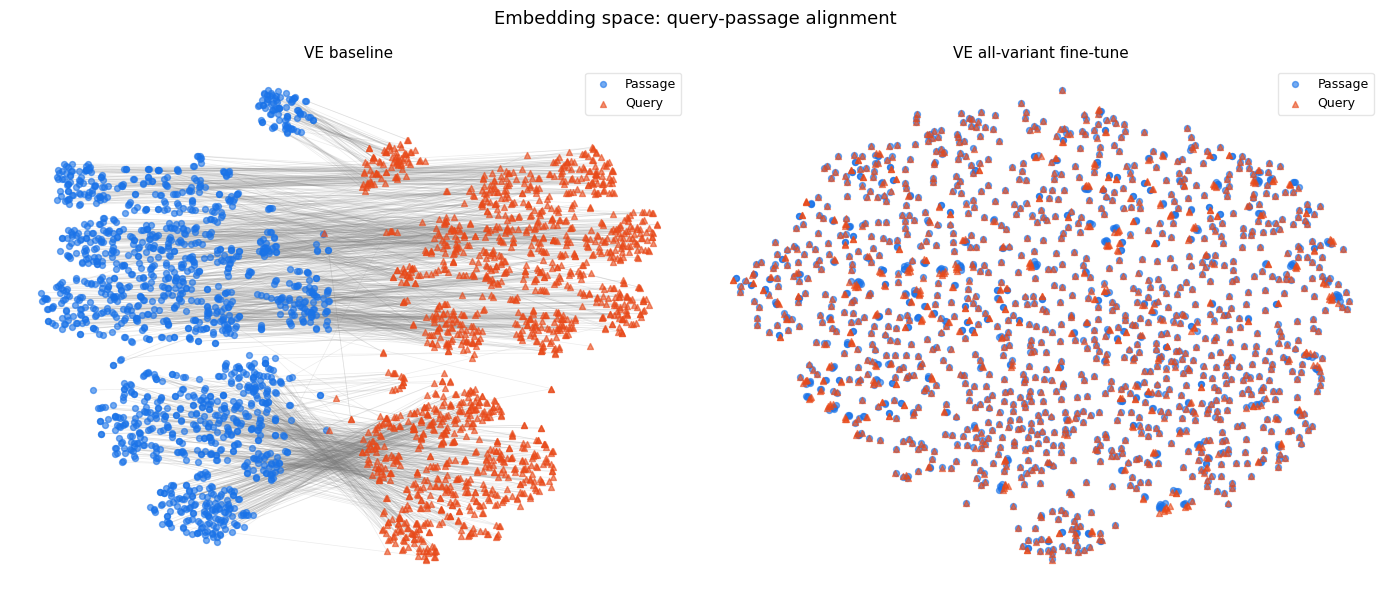

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

N_VIZ = 1500
rng = np.random.default_rng(42)
viz_idx = rng.choice(len(eval_docs), size=N_VIZ, replace=False)

viz_docs = eval_docs["document"].iloc[viz_idx].tolist() 
viz_qa = eval_qa.iloc[viz_idx].reset_index(drop=True)

query_type = "clean"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Embedding space: query-passage alignment", fontsize=13)
for ax, (label, model) in zip(axes, [
    ("VE baseline", ve_baseline),
    ("VE all-variant fine-tune", ve),
]):
    q_embs = model.encode(
        [f"query: {q}" for q in viz_qa[query_type].tolist()],
        normalize_embeddings=True,
    )
    d_embs = model.encode(
        [f"passage: {d}" for d in viz_docs],
        normalize_embeddings=True,
    )

    combined = np.vstack([q_embs, d_embs])
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    coords = tsne.fit_transform(combined)

    q_coords = coords[:N_VIZ]
    d_coords = coords[N_VIZ:]

    # Draw thin lines connecting each query to its matching passage
    for i in range(N_VIZ):
        ax.plot([q_coords[i, 0], d_coords[i, 0]],
                [q_coords[i, 1], d_coords[i, 1]],
                color="gray", alpha=0.15, linewidth=0.5, zorder=1)

    ax.scatter(d_coords[:, 0], d_coords[:, 1],
               c="#1a73e8", s=18, alpha=0.6, label="Passage", zorder=2)
    ax.scatter(q_coords[:, 0], q_coords[:, 1],
               c="#e84a1a", s=18, alpha=0.6, marker="^", label="Query", zorder=3)

    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.5)
    ax.axis("off")

plt.tight_layout()
plt.savefig('tsne_plot.png')
plt.show()

# Qualitative error analysis 

In [7]:
variant = "clean"
queries = eval_qa[variant].tolist()

doc_embs = ve.encode([f"passage: {d}" for d in eval_docs_list],
                        batch_size=32, normalize_embeddings=True)
q_embs = ve.encode([f"query: {q}" for q in queries],
                        batch_size=32, normalize_embeddings=True)

sim = cosine_similarity(q_embs, doc_embs)
ranked = np.argsort(sim, axis=1)[::-1]  # descending

# Collect failures: cases where top-1 is wrong
failures = []
for i in range(len(queries)):
    pred_idx = np.argsort(sim[i])[::-1][0]
    if pred_idx != i:
        failures.append({
            "query":    queries[i],
            "true_doc": eval_docs_list[i],
            "pred_doc": eval_docs_list[pred_idx],
        })

def classify_failure(query, true_doc, pred_doc):
    # Extract price from doc: "giá X.XX tỷ"
    def get_price(text):
        m = re.search(r"giá\s+([\d.]+)\s+tỷ", text)
        return float(m.group(1)) if m else None

    # Extract bedroom count
    def get_beds(text):
        m = re.search(r"(\d+)\s+phòng ngủ", text)
        return int(m.group(1)) if m else None

    # Extract district
    def get_district(text):
        m = re.search(r"quận\s+([\w\s]+?)(?:\s+\d|\s+diện|\s+giá|$)", text)
        return m.group(1).strip() if m else None

    # Extract area
    def get_area(text):
        m = re.search(r"diện tích\s+([\d.]+)\s+mét", text)
        return float(m.group(1)) if m else None

    true_price = get_price(true_doc)
    pred_price = get_price(pred_doc)
    true_beds  = get_beds(true_doc)
    pred_beds  = get_beds(pred_doc)
    true_dist  = get_district(true_doc)
    pred_dist  = get_district(pred_doc)
    true_area  = get_area(true_doc)
    pred_area  = get_area(pred_doc)

    # Near-duplicate: all fields match except price
    if (true_beds == pred_beds and true_dist == pred_dist and true_area == pred_area
            and true_price != pred_price):
        return "Near-duplicate listings (price only differs)"

    # Bedroom mismatch
    if true_beds != pred_beds and true_dist == pred_dist:
        return "Bedroom abbreviation mismatch"

    # District mismatch
    if true_dist != pred_dist and true_beds == pred_beds:
        return "District shorthand mismatch"

    # Area mismatch
    if true_area != pred_area and true_dist == pred_dist and true_beds == pred_beds:
        return "Area mismatch"

    return "Other"

for f in failures:
    f["failure_type"] = classify_failure(f["query"], f["true_doc"], f["pred_doc"])

failure_df = pd.DataFrame(failures)
counts = failure_df["failure_type"].value_counts().reset_index()
counts.columns = ["Failure type", "Count"]
counts["% of failures"] = (counts["Count"] / len(failures) * 100).round(1).astype(str) + "%"

# Enforce display order
order = [
    "Near-duplicate listings (price only differs)",
    "Bedroom abbreviation mismatch",
    "District shorthand mismatch",
    "Area mismatch",
    "Other",
]
counts["Failure type"] = pd.Categorical(counts["Failure type"], categories=order, ordered=True)
counts = counts.sort_values("Failure type").reset_index(drop=True)

print(f"Total failures: {len(failures)} / {len(queries)} ({len(failures)/len(queries)*100:.1f}%)\n")
display(counts.style.hide(axis="index"))

Total failures: 181 / 1500 (12.1%)



Failure type,Count,% of failures
Near-duplicate listings (price only differs),160,88.4%
Area mismatch,2,1.1%
Other,19,10.5%


In [9]:
def encode(model, texts, prefix):
    return model.encode([f"{prefix}: {t}" for t in texts], batch_size=32, normalize_embeddings=True)

def top1(q_embs, d_embs):
    return np.argmax(cosine_similarity(q_embs, d_embs), axis=1)

def print_cases(label, cases, n=3):
    print(f"\n─── {n} {label} ───")
    for i, base_pred, ft_pred in cases[:n]:
        print(f"\n  Query:        {eval_qa['code_switched'].iloc[i]}")
        print(f"  Ground truth: {eval_docs_list[i]}")
        print(f"  Baseline got: {eval_docs_list[base_pred]}")
        print(f"  Fine-tune got:{eval_docs_list[ft_pred]}")

# Encode
cs_queries = eval_qa["code_switched"].tolist()
base_top1 = top1(encode(ve_baseline, cs_queries, "query"), encode(ve_baseline, eval_docs_list, "passage"))
ft_top1   = top1(encode(ve, cs_queries, "query"), encode(ve, eval_docs_list, "passage"))

# Categorise
n = len(eval_docs_list)
wins = [(i, base_top1[i], ft_top1[i]) for i in range(n) if base_top1[i] != i and ft_top1[i] == i]
both_wrong= [(i, base_top1[i], ft_top1[i]) for i in range(n) if base_top1[i] != i and ft_top1[i] != i]

print_cases("examples where fine-tuning gets the correct retrieval and zero shot don't", wins)
print_cases("cases where both models fail to get correct retrieval", both_wrong)


─── 3 examples where fine-tuning gets the correct retrieval and zero shot don't ───

  Query:        apartment 4 BR tại Nam Từ Liêm, diện tích 150 mét vuông, giá dưới 17.3 B
  Ground truth: Căn hộ chung cư quận Nam Từ Liêm 4 phòng ngủ diện tích 150.0 mét vuông giá 16.80 tỷ đồng
  Baseline got: Nhà quận Bắc Từ Liêm 4 phòng ngủ diện tích 65.0 mét vuông giá 17.00 tỷ đồng
  Fine-tune got:Căn hộ chung cư quận Nam Từ Liêm 4 phòng ngủ diện tích 150.0 mét vuông giá 16.80 tỷ đồng

  Query:        house tại Hoàng Mai, 5 BR, 90 mét vuông, giá dưới 23.5 B.
  Ground truth: Nhà quận Hoàng Mai 5 phòng ngủ diện tích 90.0 mét vuông giá 23.00 tỷ đồng
  Baseline got: Nhà quận Hoàng Mai 5 phòng ngủ diện tích 225.0 mét vuông giá 21.50 tỷ đồng
  Fine-tune got:Nhà quận Hoàng Mai 5 phòng ngủ diện tích 90.0 mét vuông giá 23.00 tỷ đồng

  Query:        house tại Long Biên, 4 BR, 65 mét vuông, giá dưới 21.0 B
  Ground truth: Nhà quận Long Biên 4 phòng ngủ diện tích 65.0 mét vuông giá 20.50 tỷ đồng
  Baseline go